### [과제- fish.csv 기반 분류 모델 코드 구현 ] <hr>

- **[0] 모듈 로딩**

In [1]:
## -------------------------------------
## 이미지 데이터 로딩 & 기본 정보
## -------------------------------------
import cv2
import os
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import numpy as np
import matplotlib.cm as cm
import sys
sys.path.append(r"C:\KDT14\7_CV")
import importlib
import cv_utils
importlib.reload(cv_utils)

from sklearn.model_selection import train_test_split #학습용| 테스트용 데이터 분할
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier # 모델클래스
from sklearn.metrics import accuracy_score, classification_report # 평가
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

- **[1] 데이터 준비**

In [2]:
DATA_FILE= './fish.csv'

#  데이터 로딩
dataDF= pd.read_csv(DATA_FILE)
dataDF

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...
154,Smelt,12.2,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,14.3,15.2,2.8728,2.0672


In [15]:
print("============== 구조 요약 ==============")
dataDF.info()


print("\n============== 상위 3개 행 ==============")
display(dataDF.head(3))
# 데이터가 어떤 형태로 들어있는지 앞에서부터 3개 행 확인


print("\n============== 기초 통계 요약 ==============")
display(dataDF.describe(include='all'))
# 데이터의 기초 통계 확인
# include='all' : 숫자형 컬럼뿐만 아니라 문자형 컬럼까지 함께 확인
# 확인 결과 unique--> 7 으로 빙어, 도미 외 종 존재



## 0번째 컬럼이 타겟== Species
## 특징은 너비Width, 높이Height, 무게Weight 3가지 

============== 구조 요약 ==============
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Species   159 non-null    category
 1   Weight    159 non-null    float64 
 2   Length    159 non-null    float64 
 3   Diagonal  159 non-null    float64 
 4   Height    159 non-null    float64 
 5   Width     159 non-null    float64 
dtypes: category(1), float64(5)
memory usage: 6.8 KB

============== 상위 3개 행 ==============


,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961



============== 기초 통계 요약 ==============


,Species,Weight,Length,Diagonal,Height,Width
count,159,159.000000,159.000000,159.000000,159.000000,159.000000
unique,7,NaN,NaN,NaN,NaN,NaN
top,Perch,NaN,NaN,NaN,NaN,NaN
freq,56,NaN,NaN,NaN,NaN,NaN
mean,NaN,398.326415,28.415723,31.227044,8.970994,4.417486
std,NaN,357.978317,10.716328,11.610246,4.286208,1.685804
min,NaN,0.000000,8.400000,8.800000,1.728400,1.047600
25%,NaN,120.000000,21.000000,23.150000,5.944800,3.385650
50%,NaN,273.000000,27.300000,29.400000,7.786000,4.248500
75%,NaN,650.000000,35.500000,39.650000,12.365900,5.584500


- **[2] 데이터 전처리**

In [7]:
dataDF.Species=dataDF.Species.astype('category')

display(dataDF.dtypes)

Species     category
Weight       float64
Length       float64
Diagonal     float64
Height       float64
Width        float64
dtype: object

- **[3]학습용|테스트용 데이터셋 준비**

In [22]:
## => 피쳐와 타겟 분리
featureDF = dataDF[['Weight', 'Height', 'Width']]
targetSR = dataDF['Species']

print(f'피쳐 : {featureDF.shape}, 타겟 : {targetSR.shape}')

피쳐 : (159, 3), 타겟 : (159,)


In [27]:
# 도미, 빙어 데이터만 추출
fishDF = dataDF[dataDF['Species'].isin(['Bream', 'Smelt'])].copy()

# 타겟을 category 타입으로 변경
fishDF['Species'] = fishDF['Species'].astype('category')

# 피쳐와 타겟 분리
featureDF = fishDF[['Weight', 'Height', 'Width']]
targetSR = fishDF['Species']

print(f'피쳐 : {featureDF.shape}, 타겟 : {targetSR.shape}')
print(targetSR.value_counts())

피쳐 : (49, 3), 타겟 : (49,)
Species
Bream        35
Smelt        14
Parkki        0
Perch         0
Pike          0
Roach         0
Whitefish     0
Name: count, dtype: int64


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    featureDF,
    targetSR,
    test_size=0.2,
    random_state=10,
    stratify=targetSR
)

print(f'학습용 : {X_train.shape}, {y_train.shape}')
print(f'테스트용 : {X_test.shape}, {y_test.shape}')

print('\n학습용 클래스 데이터 구성')
print(y_train.value_counts())

print('\n테스트용 클래스 데이터 구성')
print(y_test.value_counts())

학습용 : (39, 3), (39,)
테스트용 : (10, 3), (10,)

학습용 클래스 데이터 구성
Species
Bream        28
Smelt        11
Parkki        0
Perch         0
Pike          0
Roach         0
Whitefish     0
Name: count, dtype: int64

테스트용 클래스 데이터 구성
Species
Bream        7
Smelt        3
Parkki       0
Perch        0
Pike         0
Roach        0
Whitefish    0
Name: count, dtype: int64


- **하이퍼파라미터 튜닝**

In [ ]:

# 모델 생성
kModel = KNeighborsClassifier()

# 하이퍼파라미터 후보
param_dict = {
    'n_neighbors': range(1, 31, 2),
    'p': [1, 2],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
}

# 교차검증 방식
skFold = StratifiedKFold(n_splits=5, shuffle=True, random_state=10)

In [33]:
## => 학습 후 설정된 모델 파라미터 확인
## - cv_results_ : 각 모델의 교차검증 결과 저장 dict 형식


gsModel = GridSearchCV(
    kModel,
    param_grid=param_dict,
    cv=skFold,
    return_train_score=True
)


## 하이퍼파라미터 조합으로 모델 생성 및 교차검증 학습 진행
## => Y_TRAIN에 따라서 KFold, StatifiedFold로 선택됨
gsModel.fit(X_train, y_train)

cv_resultDF = pd.DataFrame(gsModel.cv_results_)

print("GridSearchCV 최적 파라미터:", gsModel.best_params_)
print("GridSearchCV 최고 검증 점수:", gsModel.best_score_)
print("GridSearchCV 테스트 점수:", gsModel.best_estimator_.score(X_test, y_test))

## - best_estimator_ : 최고 성능의 조합으로 재학습한 모델인스턴스
gs_best_model = gsModel.best_estimator_

GridSearchCV 최적 파라미터: {'algorithm': 'auto', 'n_neighbors': 1, 'p': 1}
GridSearchCV 최고 검증 점수: 1.0
GridSearchCV 테스트 점수: 1.0


In [34]:
## 학습 후 설정된 모델 파라미터 확인
gsModel.cv_results_

{'mean_fit_time': array([0.00182419, 0.00238132, 0.0023994 , 0.00205536, 0.00105267,
        0.00096912, 0.00226045, 0.00168052, 0.00088367, 0.00140648,
        0.00215764, 0.00100832, 0.00121555, 0.0021172 , 0.00100207,
        0.00342264, 0.00072765, 0.00137229, 0.00252042, 0.00162573,
        0.00140362, 0.00065923, 0.00157852, 0.00125604, 0.00051985,
        0.00091276, 0.0010417 , 0.00152984, 0.00141525, 0.00063753,
        0.00112896, 0.00163913, 0.00159698, 0.00111804, 0.00108285,
        0.00161819, 0.00146599, 0.00200553, 0.00140371, 0.00215397,
        0.00096035, 0.00112801, 0.00167832, 0.00117884, 0.00038233,
        0.00166082, 0.0012887 , 0.00178289, 0.00065145, 0.0008029 ,
        0.00144663, 0.00293584, 0.00214872, 0.00189118, 0.00214639,
        0.00216413, 0.00200176, 0.00129142, 0.00121217, 0.00198026,
        0.00076208, 0.0015132 , 0.00075474, 0.00391622, 0.00094461,
        0.00102139, 0.0005044 , 0.00109982, 0.00251451, 0.00172534,
        0.00102944, 0.00197873,

In [35]:
## => 학습 후 설정된 모델 파라미터 확인
## - cv_results_ : 각 모델의 교차검증 결과 저장 dict 형식
cv_resultDF = pd.DataFrame(gsModel.cv_results_)

## - best_params_ : 최고 성능의 하이퍼파라미터 조합
print(f'gsModel.best_params _: {gsModel.best_params_}=> {gsModel.best_score_:.4f}')

bestModel= gsModel.best_estimator_

gsModel.best_params _: {'algorithm': 'auto', 'n_neighbors': 1, 'p': 1}=> 1.0000


In [36]:
## => 모델 조합별 교차검증 결과
cv_resultDF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   mean_fit_time       120 non-null    float64
 1   std_fit_time        120 non-null    float64
 2   mean_score_time     120 non-null    float64
 3   std_score_time      120 non-null    float64
 4   param_algorithm     120 non-null    object 
 5   param_n_neighbors   120 non-null    int64  
 6   param_p             120 non-null    int64  
 7   params              120 non-null    object 
 8   split0_test_score   120 non-null    float64
 9   split1_test_score   120 non-null    float64
 10  split2_test_score   120 non-null    float64
 11  split3_test_score   120 non-null    float64
 12  split4_test_score   120 non-null    float64
 13  mean_test_score     120 non-null    float64
 14  std_test_score      120 non-null    float64
 15  rank_test_score     120 non-null    int32  
 16  split0_t

In [38]:

## => 모델 조합별 교차검증 결과
cv_resultDF.info()

## => 확인하고 싶은 컬럼만 선택
cols =['rank_test_score', 'param_algorithm', 'param_n_neighbors', 'param_p', 'mean_test_score']

display(cv_resultDF[cols])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   mean_fit_time       120 non-null    float64
 1   std_fit_time        120 non-null    float64
 2   mean_score_time     120 non-null    float64
 3   std_score_time      120 non-null    float64
 4   param_algorithm     120 non-null    object 
 5   param_n_neighbors   120 non-null    int64  
 6   param_p             120 non-null    int64  
 7   params              120 non-null    object 
 8   split0_test_score   120 non-null    float64
 9   split1_test_score   120 non-null    float64
 10  split2_test_score   120 non-null    float64
 11  split3_test_score   120 non-null    float64
 12  split4_test_score   120 non-null    float64
 13  mean_test_score     120 non-null    float64
 14  std_test_score      120 non-null    float64
 15  rank_test_score     120 non-null    int32  
 16  split0_t

,rank_test_score,param_algorithm,param_n_neighbors,param_p,mean_test_score
0,1,auto,1,1,1.000000
1,1,auto,1,2,1.000000
2,1,auto,3,1,1.000000
3,1,auto,3,2,1.000000
4,1,auto,5,1,1.000000
...,...,...,...,...,...
115,73,brute,25,2,0.717857
116,73,brute,27,1,0.717857
117,73,brute,27,2,0.717857
118,73,brute,29,1,0.717857


In [41]:
param_dict ={'n_neighbors' : range(1,31,2), 'p':[1,2], 'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']}

## => 튜닝 및 교차검증 진행 인스턴스
gsModel = GridSearchCV(kModel, param_grid=param_dict, return_train_score=True)

In [42]:
gsModel.fit(X_train, y_train)

GridSearchCV(estimator=KNeighborsClassifier(),
             param_grid={'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
                         'n_neighbors': range(1, 31, 2), 'p': [1, 2]},
             return_train_score=True)

In [ ]:
cv_resultDF.info()

cols =['rank_test_score', 'param_algorithm', 'param_n_neighbors', 'param_p', 'mean_test_score']

selDF= cv_resultDF[cols]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   mean_fit_time       120 non-null    float64
 1   std_fit_time        120 non-null    float64
 2   mean_score_time     120 non-null    float64
 3   std_score_time      120 non-null    float64
 4   param_algorithm     120 non-null    object 
 5   param_n_neighbors   120 non-null    int64  
 6   param_p             120 non-null    int64  
 7   params              120 non-null    object 
 8   split0_test_score   120 non-null    float64
 9   split1_test_score   120 non-null    float64
 10  split2_test_score   120 non-null    float64
 11  split3_test_score   120 non-null    float64
 12  split4_test_score   120 non-null    float64
 13  mean_test_score     120 non-null    float64
 14  std_test_score      120 non-null    float64
 15  rank_test_score     120 non-null    int32  
 16  split0_t

In [44]:
selDF.sort_values(by= ['rank_test_score'])
cv_resultDF.iloc[14]

mean_fit_time                                                 0.001002
std_fit_time                                                   0.00156
mean_score_time                                               0.004833
std_score_time                                                0.001258
param_algorithm                                                   auto
param_n_neighbors                                                   15
param_p                                                              1
params                {'algorithm': 'auto', 'n_neighbors': 15, 'p': 1}
split0_test_score                                                  1.0
split1_test_score                                                  1.0
split2_test_score                                                  1.0
split3_test_score                                                  1.0
split4_test_score                                                  1.0
mean_test_score                                                    1.0
std_te

In [45]:
## ------------------------------------------
## => RandomizedSearchCV 인스턴스 생성 및 진행
## - GridSearchCV 보다 빠르지만 성능이 안 좋을수도 있음
## - 지정된 개수 만큼의 모델을 조합 => 속도 빠름
## - 조합된 모델별 교차 검증 진행
## - 단점 : GridSearchCV보다 최적의 조합 아닐 수 도 있음
## cv 파라미터
##   * 기본값 : 5
##   * 학습 시 전달하는 y값에 따라서 KFold, StratifiedKFold 설정
## - random_state 파라미터
##   * 재현성 위해서 설정
## - n_iter 파라미터
##   * 무작위 조합할 모델 개수 설정
## ------------------------------------------


## => 교차검증 인스턴스 생성
skFold = StratifiedKFold(n_splits=5, shuffle=True, random_state=10)

## => 튜닝 및 교차검증 진행 인스턴스
rsModel = RandomizedSearchCV(kModel, param_distributions=param_dict, cv=skFold, n_iter=50, random_state= 10, return_train_score=True)



In [46]:
## 교차검증 진행
rsModel.fit(X_train, y_train)

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=10, shuffle=True),
                   estimator=KNeighborsClassifier(), n_iter=50,
                   param_distributions={'algorithm': ['auto', 'ball_tree',
                                                      'kd_tree', 'brute'],
                                        'n_neighbors': range(1, 31, 2),
                                        'p': [1, 2]},
                   random_state=10, return_train_score=True)

In [47]:
print(f'최고조합: {rsModel.best_params_} , 최고점수: {rsModel.best_score_}')

## 최고 조합으로 재학습된 모델 인스턴스
rs_best_model= rsModel.best_estimator_

## 조합 모델 별 학습 성능
cv_resultDF= pd.DataFrame(rsModel.cv_results_)
cv_resultDF.info()

최고조합: {'p': 2, 'n_neighbors': 15, 'algorithm': 'ball_tree'} , 최고점수: 1.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   mean_fit_time       50 non-null     float64
 1   std_fit_time        50 non-null     float64
 2   mean_score_time     50 non-null     float64
 3   std_score_time      50 non-null     float64
 4   param_p             50 non-null     int64  
 5   param_n_neighbors   50 non-null     int64  
 6   param_algorithm     50 non-null     object 
 7   params              50 non-null     object 
 8   split0_test_score   50 non-null     float64
 9   split1_test_score   50 non-null     float64
 10  split2_test_score   50 non-null     float64
 11  split3_test_score   50 non-null     float64
 12  split4_test_score   50 non-null     float64
 13  mean_test_score     50 non-null     float64
 14  std_test_score      50 non-null     

In [48]:
## 사용자로부터 입력받은 값 예측
in_data = input("생선 스펙 입력(예: 8 10 14):").split(" ")
newDF = pd.DataFrame([in_data], columns=X_train.columns)
print(newDF)


gs_best_model = gsModel.best_estimator_
## 예측 진행
y_pre = gs_best_model.predict(newDF)

print(y_pre)

  Weight Height Width
0      8     14     5
['Smelt']


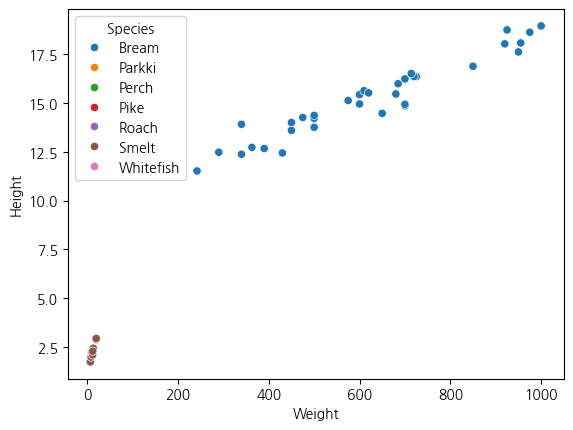

In [50]:
import seaborn as sns

sns.scatterplot(
    data=dataDF[dataDF['Species'].isin(['Bream', 'Smelt'])],
    x='Weight',
    y='Height',
    hue='Species'
)

plt.show()